# 핵심 결과 — DepMap Mutation 기반 유전체 불안정성 예측

DepMap mutation만으로 WGD/CIN/LOH를 예측하고 최소 biomarker panel을 찾는
프로젝트의 핵심 결과만 간결하게 정리한 노트북이다. 전체 파이프라인은
`01_full_pipeline.ipynb`, 전체 문서는 https://github.com/lkeonwoo94/AI-bio-proj-team-1 참고.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from IPython.display import Image, display

TABLES = REPO_ROOT / "results" / "tables"
FIGURES = REPO_ROOT / "results" / "figures"
pd.set_option("display.width", 120)

## 1. 데이터

DepMap Public 26Q1, 1,631개 세포주, hotspot 554 + damaging 19,578 mutation
feature. 정답 라벨(WGD/CIN/LoHFraction)은 `OmicsGlobalSignatures.csv`.

In [2]:
from src.data.merge import load_cohort

cohort = load_cohort()
print(cohort.summary())

세포주 1,631 | feature 20,132 (hotspot 554 / damaging 19,578) | lineage 32종


## 2. 모델 비교 — Random Forest가 최고 성능

5개 모델(Logistic/Elastic Net/Random Forest/XGBoost/CatBoost) × 3표현형을
nested CV(outer 5×inner 5)로 비교했다.

In [3]:
day10 = pd.read_csv(TABLES / "day10_model_comparison.csv")
day10.pivot(index="model", columns="target", values="roc_auc")[["wgd","cin","loh"]] \
    .sort_values("wgd", ascending=False).round(3)

target,wgd,cin,loh
model,,,
random_forest,0.765,0.734,0.730
catboost,0.762,0.711,0.717
xgboost,0.757,0.729,0.728
elastic_net,0.749,0.681,0.711
logistic,0.723,0.672,0.683
multitask_ann,0.704,0.671,0.667


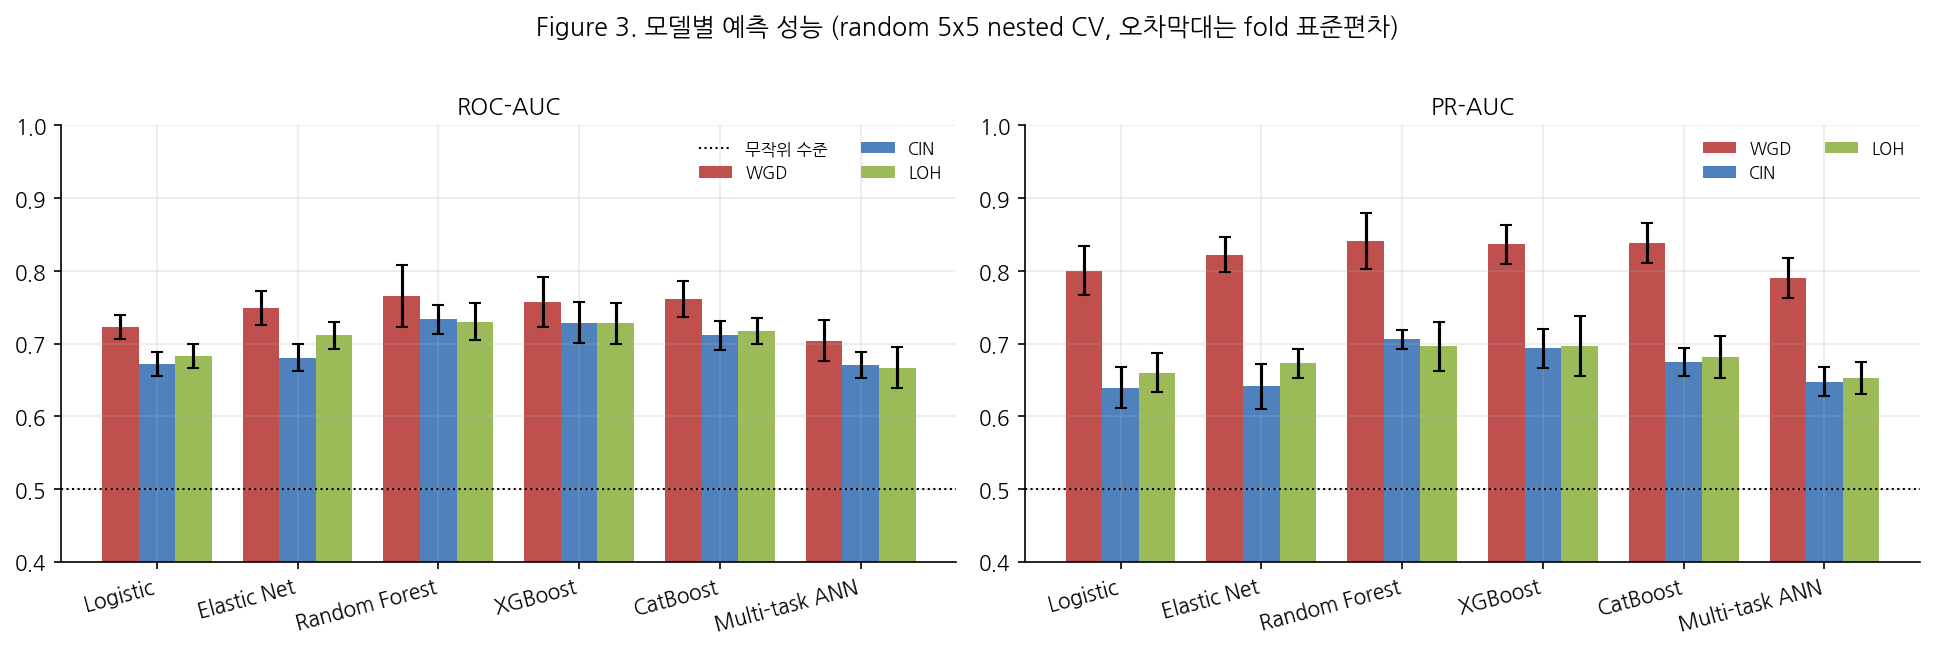

In [4]:
display(Image(filename=str(FIGURES / "fig3_model_comparison.png")))

## 3. Random Forest Confusion Matrix

5개 outer fold의 test 예측을 pooled 한 confusion matrix.

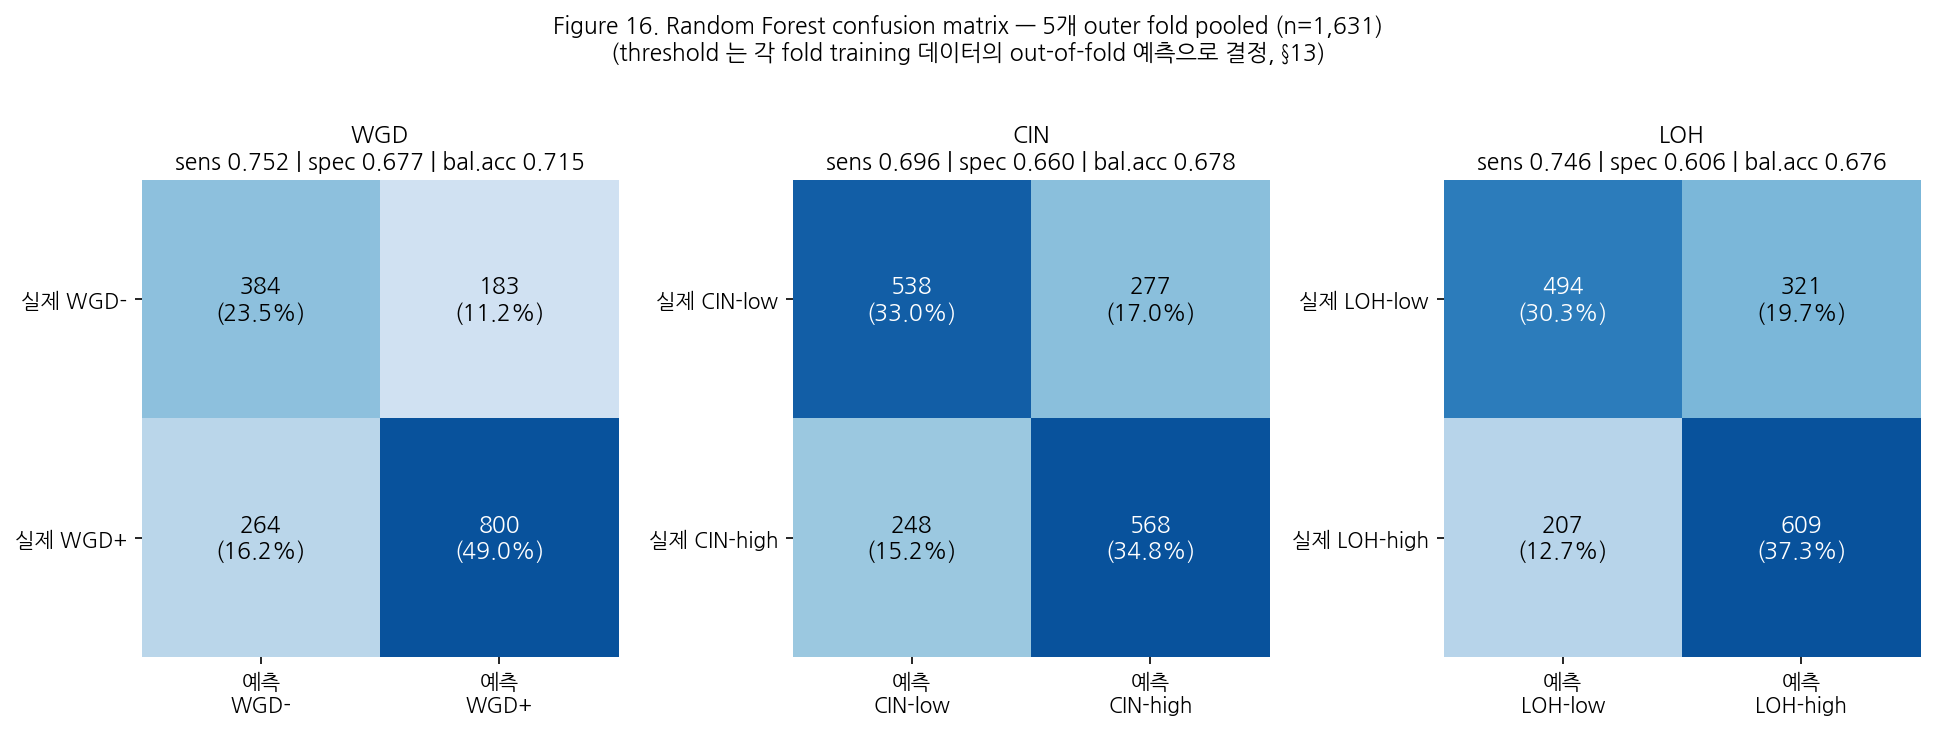

In [5]:
display(Image(filename=str(FIGURES / "fig16_rf_confusion_matrix.png")))

## 4. Feature Importance — 어떤 mutation이 중요한가

각 outer fold의 training data에서 feature selection을 반복해, 5개 fold
전부에서 선택된("전 fold 공통") 유전자를 찾는다(Random Forest 기준).

In [6]:
for target in ("wgd", "cin", "loh"):
    df = pd.read_csv(TABLES / f"day11_selection_random_forest_{target}.csv")
    common = df[df.selection_freq == 1.0]
    genes = ", ".join(common.gene.head(8))
    print(f"{target.upper()}: 전 fold(5/5) 공통 {len(common)}개 — {genes}")

WGD: 전 fold(5/5) 공통 19개 — TP53, TP53, TERT, BRAF, ID3, LRP1B, TTN, KRAS
CIN: 전 fold(5/5) 공통 21개 — TP53, TP53, TERT, RB1, ID3, BRAF, PIK3CA, KRAS
LOH: 전 fold(5/5) 공통 18개 — TP53, TP53, RB1, ID3, KRAS, NF2, ARID1A, PITX1


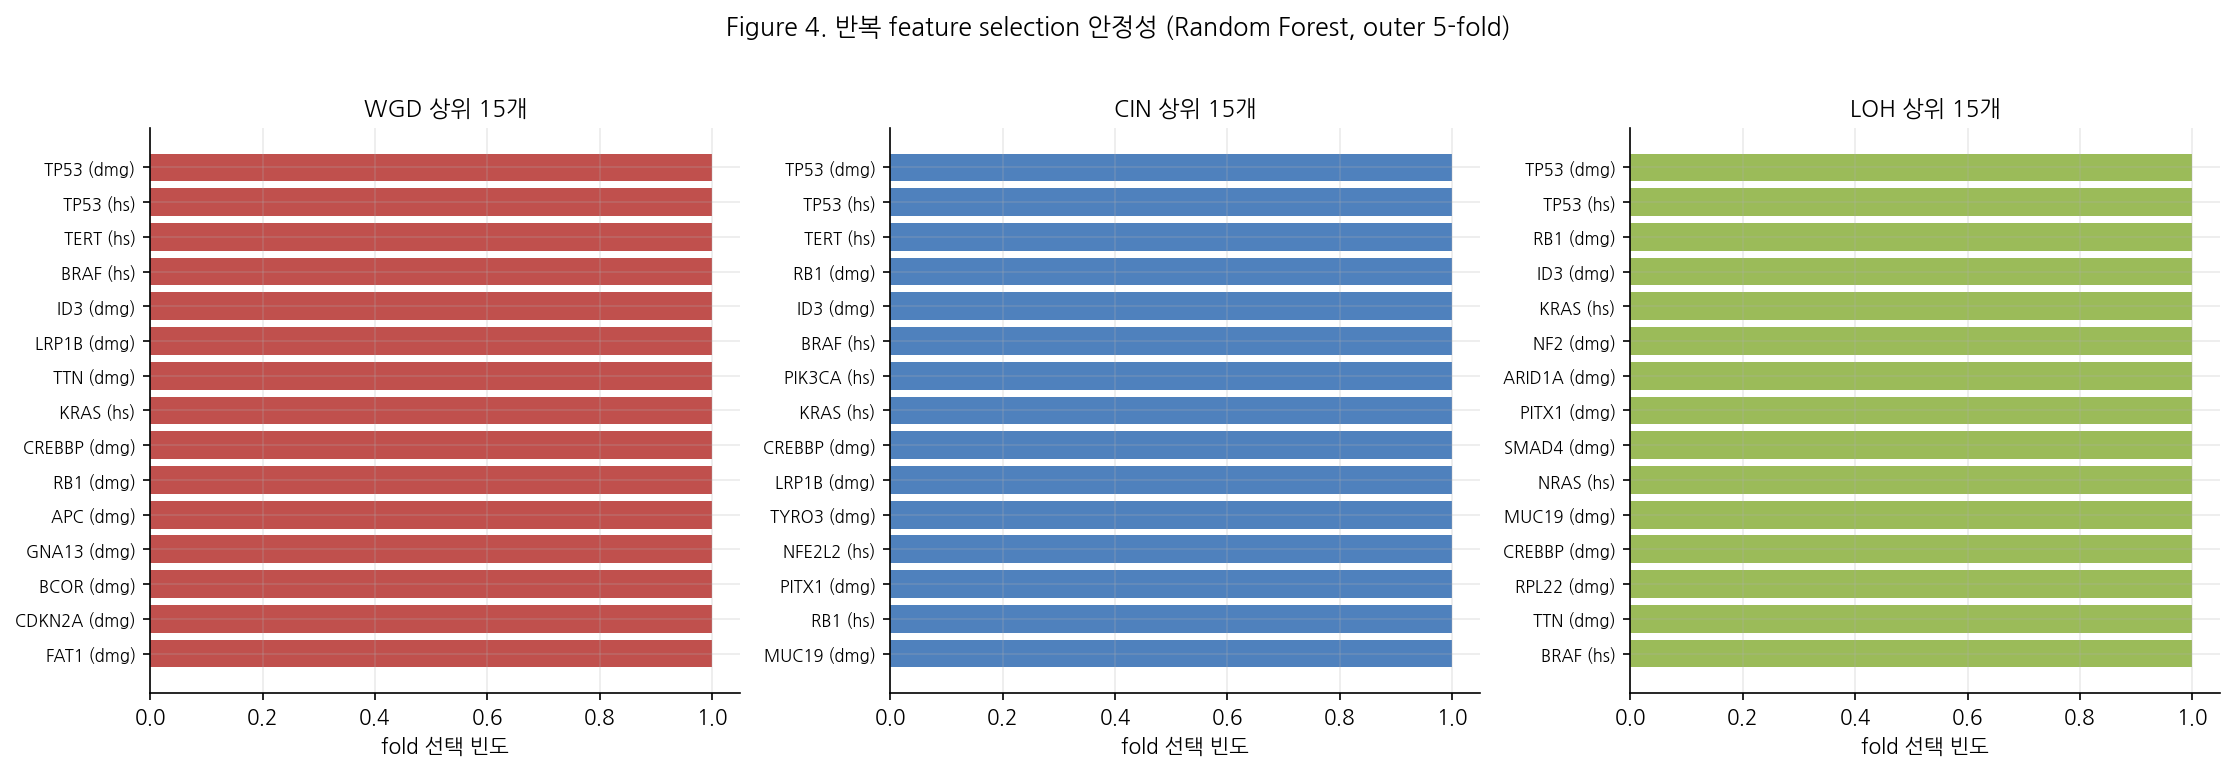

In [7]:
display(Image(filename=str(FIGURES / "fig4_selection_stability_random_forest.png")))

**TP53이 세 표현형 모두에서 압도적 1위**(평균 순위 1.0, 순위 표준편차 0)다.
ID3·BRAF·CREBBP도 세 표현형 공통 후보로 반복 선택된다.

## 5. 최소 Mutation Panel

10개 mutation으로 전체 성능의 93\~99%가 유지된다.

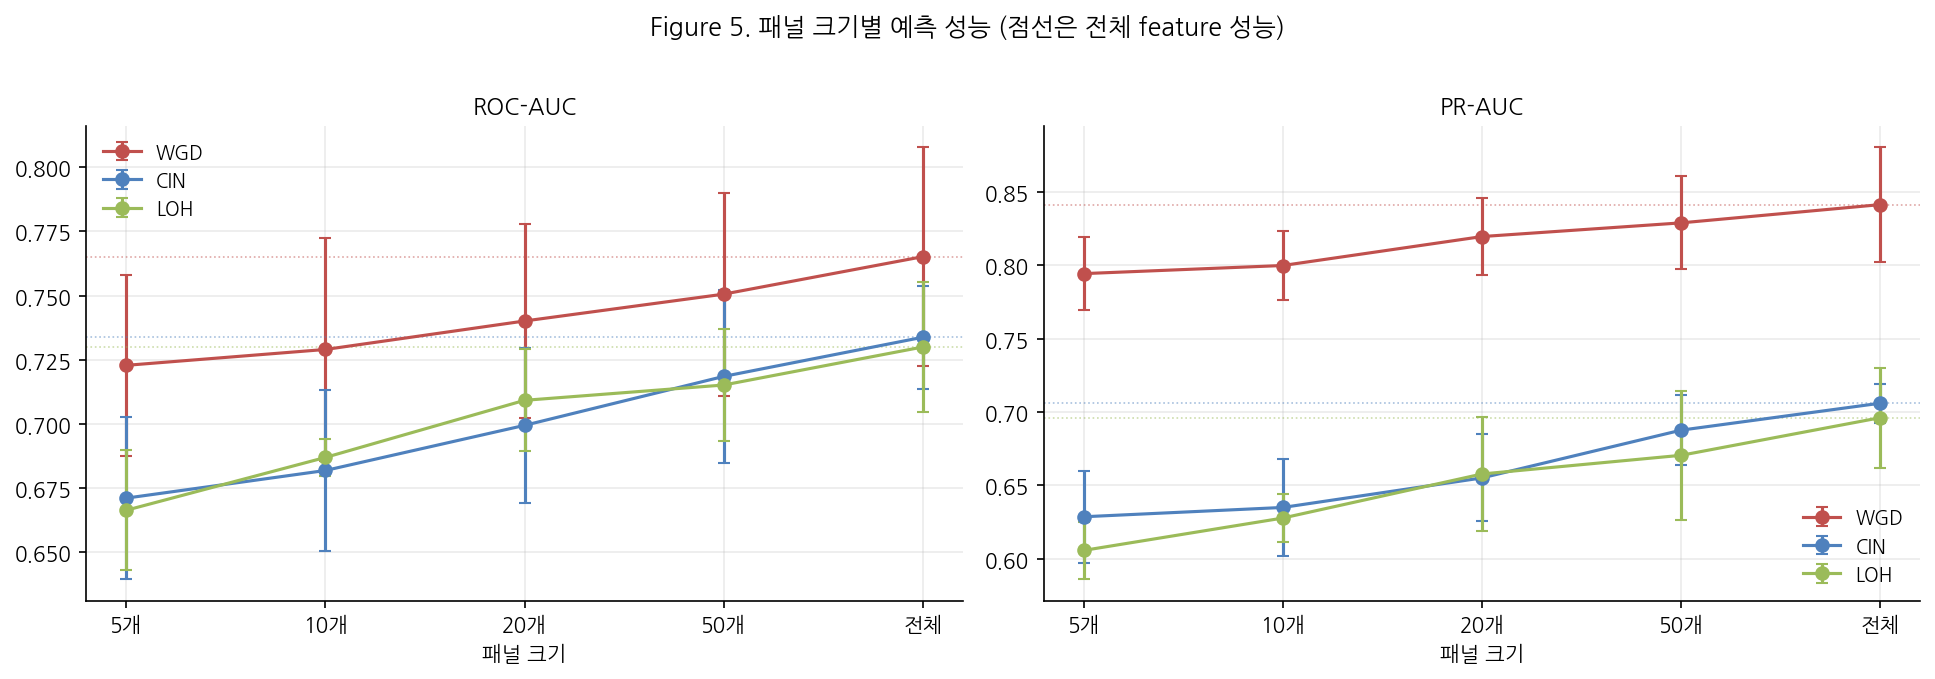

In [8]:
display(Image(filename=str(FIGURES / "fig5_panel_curve_random_forest.png")))

## 6. 후속 실험 — Pathway(음성) vs Signature(양성) vs 결합(항상 개선)

Pathway 재집계 — 6/6 조합 전부 하락 (음성)


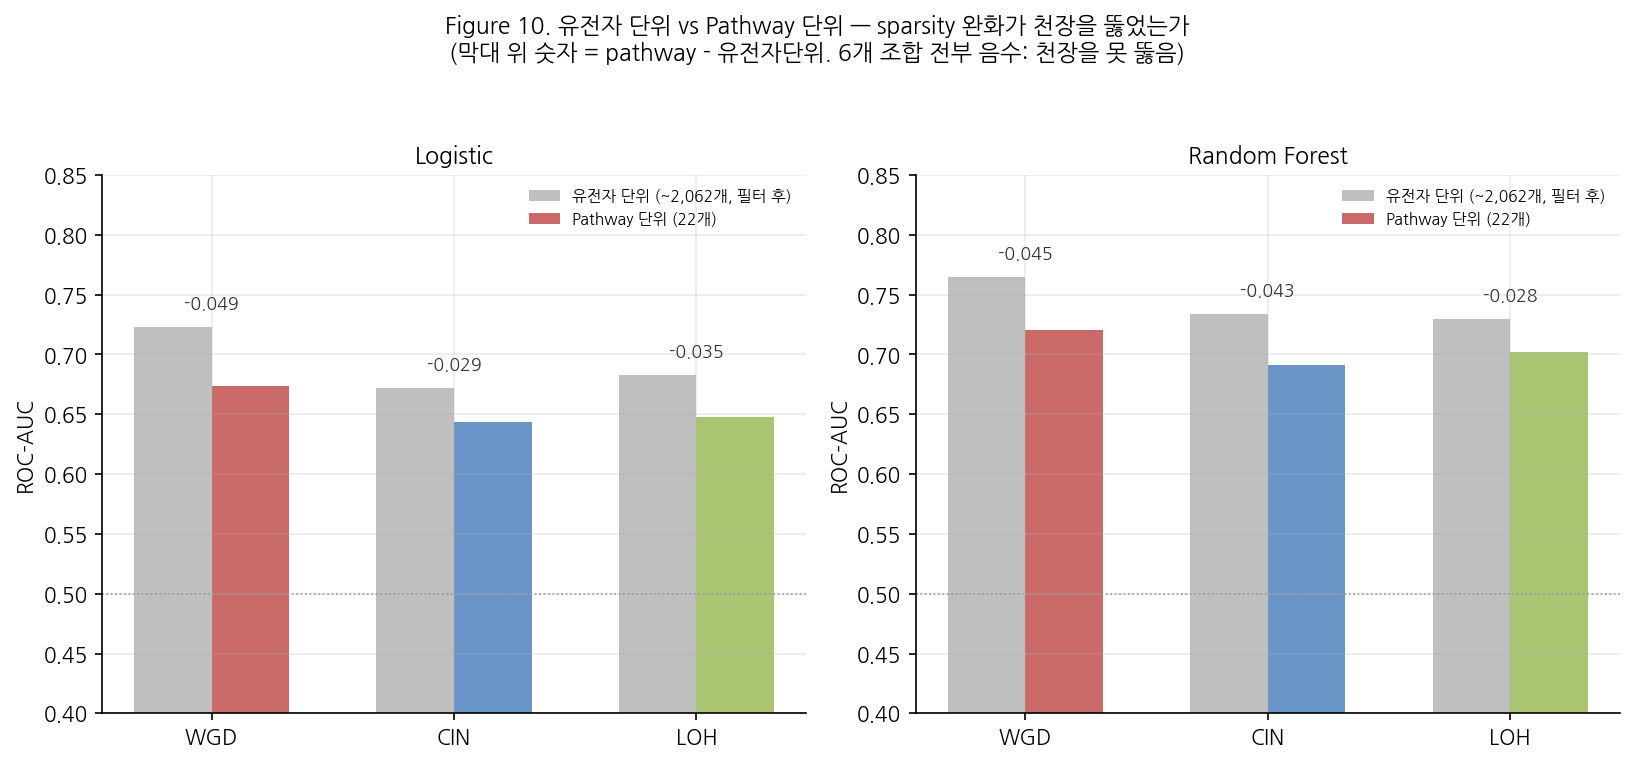

Mutation signature(96-class) — 5/6 조합 개선 (양성)


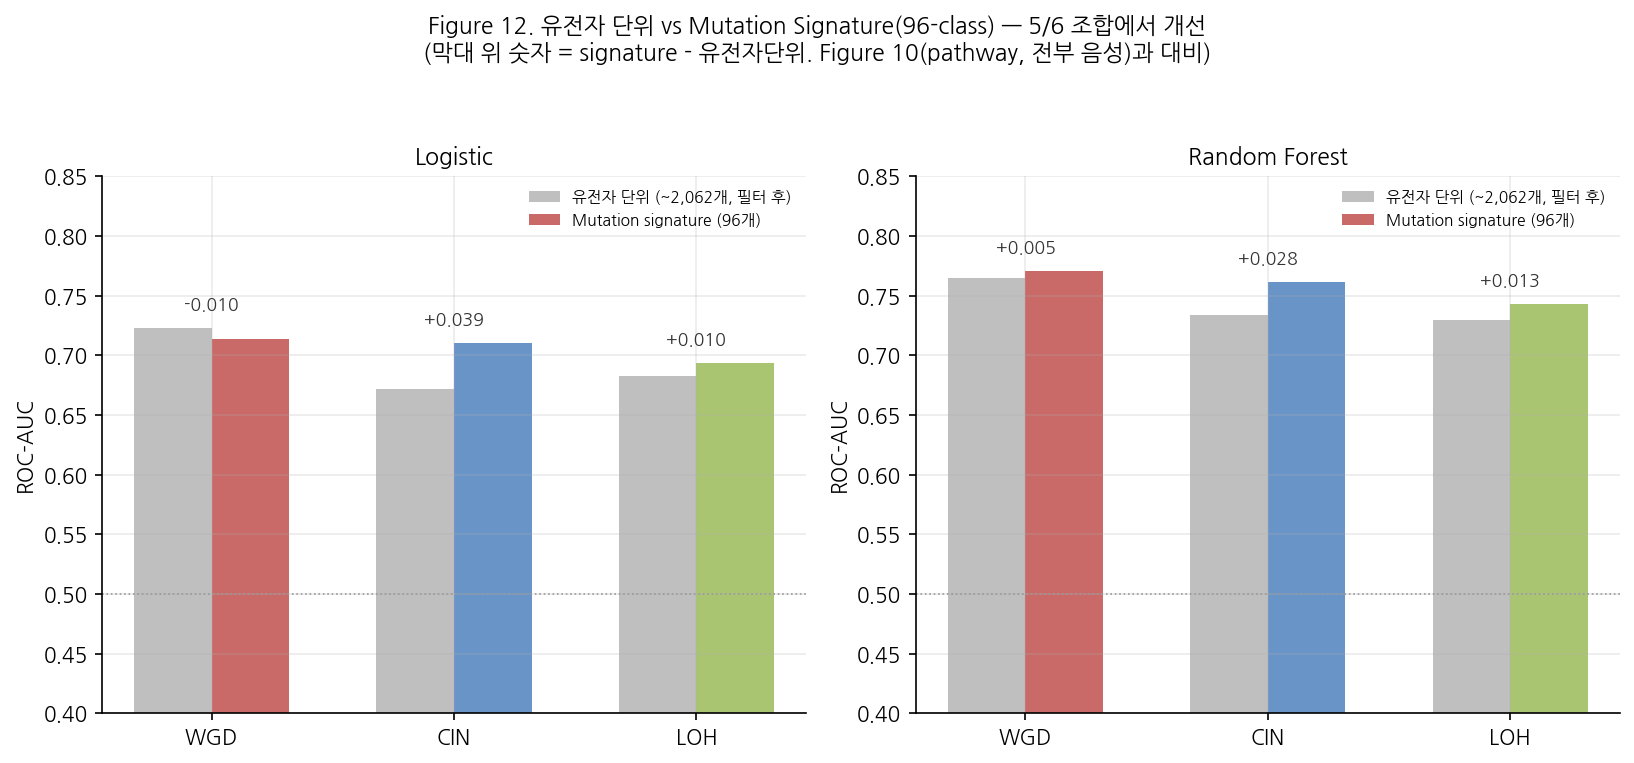

유전자+Signature 결합 — 6/6 조합 전부 개선


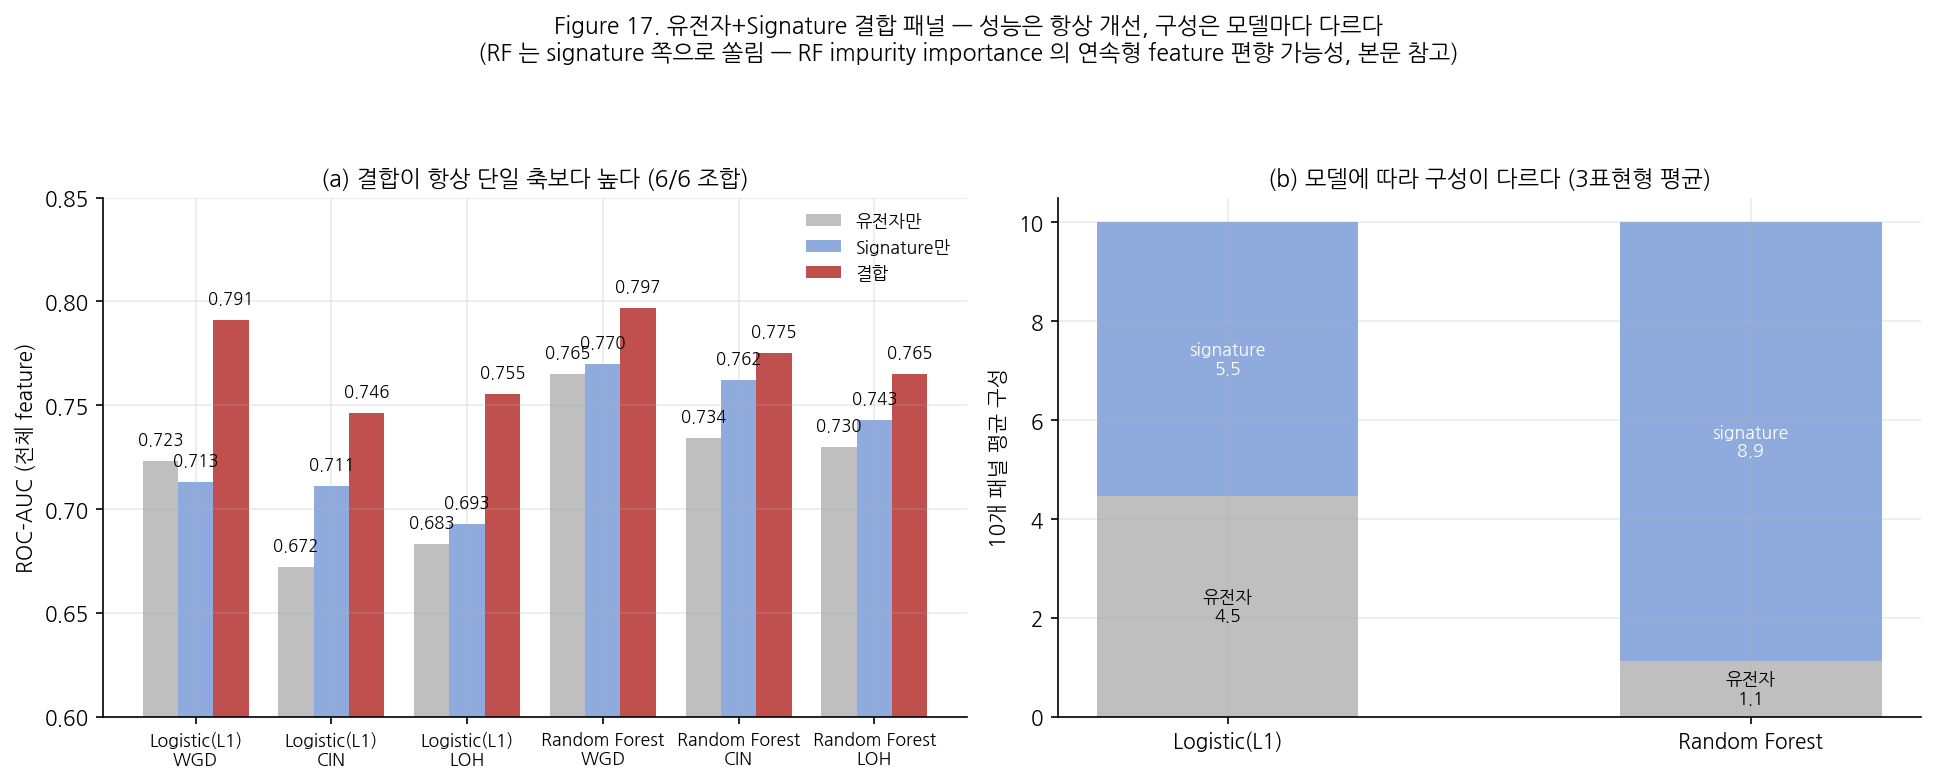

In [9]:
fig, axes = None, None
for name, caption in [
    ("fig10_pathway_vs_gene.png", "Pathway 재집계 — 6/6 조합 전부 하락 (음성)"),
    ("fig12_signature_vs_gene.png", "Mutation signature(96-class) — 5/6 조합 개선 (양성)"),
    ("fig17_combined_panel.png", "유전자+Signature 결합 — 6/6 조합 전부 개선"),
]:
    print(caption)
    display(Image(filename=str(FIGURES / name)))

## 7. TCGA 외부 코호트 검증

세포주가 아닌 실제 환자 종양(TCGA)에서 WGD를 검증 — 내부 0.762 → 외부 0.594
(방법론적 한계로 인한 하한 추정치, 상세는 전체 노트북 §13 참고).

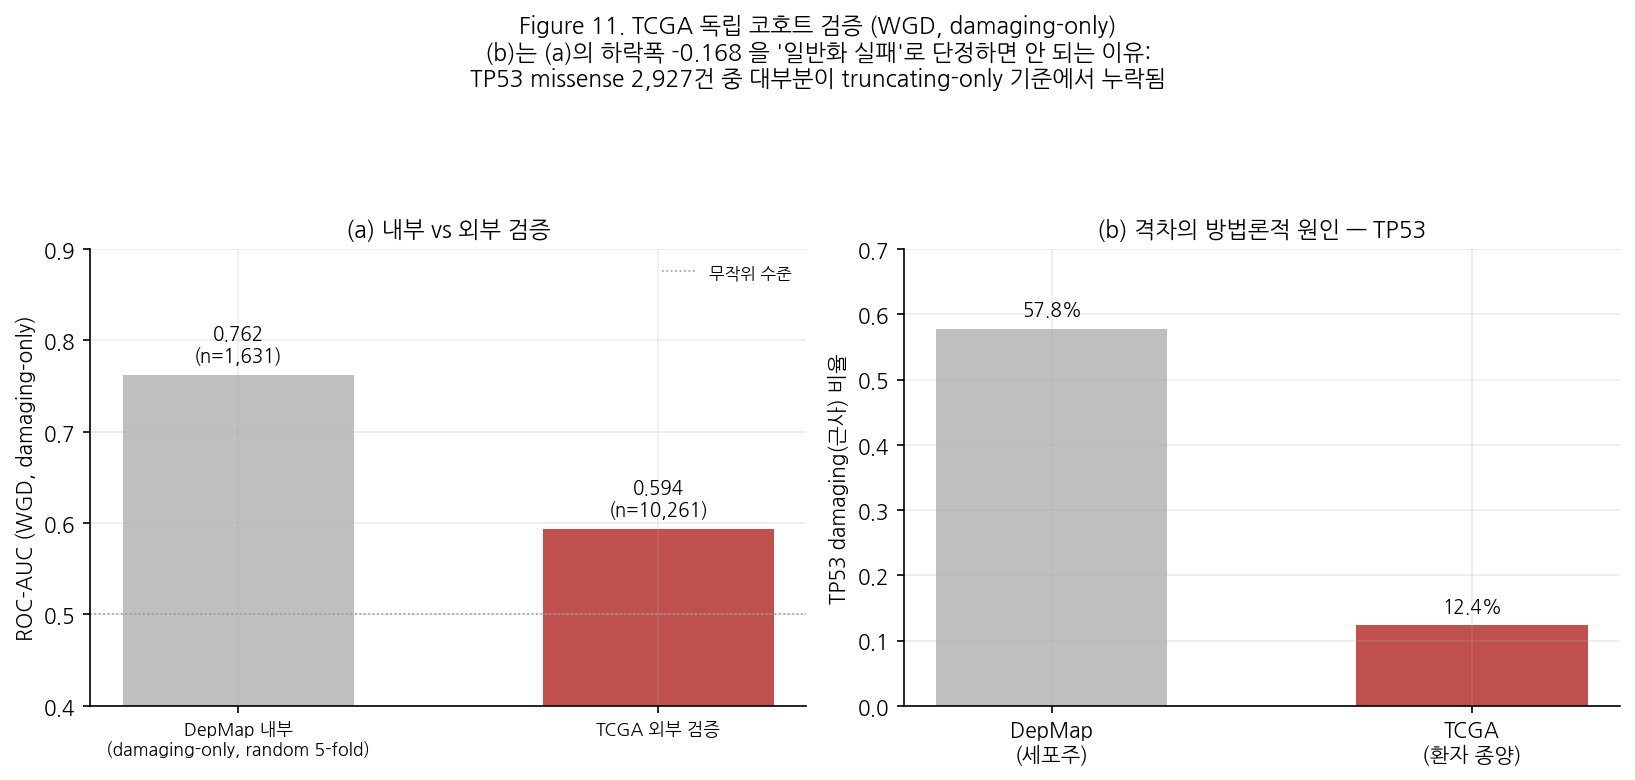

In [10]:
display(Image(filename=str(FIGURES / "fig11_tcga_validation.png")))

## 8. 최종 후보 Biomarker Panel (8개 유전자)

fold 반복·모델 간 합의·회귀 재검증·TCGA 방향성 지지를 종합한 최종 후보.

In [11]:
panel = pd.DataFrame([
    ("TP53", "damaging+hotspot", "WGD/CIN/LOH 공통", "세 표현형 전부 평균 순위 1위"),
    ("ID3", "damaging", "WGD/CIN/LOH 공통", ""),
    ("BRAF", "hotspot", "WGD/CIN/LOH 공통", ""),
    ("CREBBP", "damaging", "WGD/CIN/LOH 공통", ""),
    ("TERT", "hotspot", "WGD 특이", "telomerase 역전사효소"),
    ("RB1", "damaging", "CIN 특이", "G1/S checkpoint tumor suppressor"),
    ("PIK3CA", "hotspot", "CIN 특이", "PI3K 촉매 subunit"),
    ("PITX1", "damaging", "LOH 특이", "발생 전사인자"),
], columns=["gene", "type", "role", "note"])
panel

,gene,type,role,note
0,TP53,damaging+hotspot,WGD/CIN/LOH 공통,세 표현형 전부 평균 순위 1위
1,ID3,damaging,WGD/CIN/LOH 공통,
2,BRAF,hotspot,WGD/CIN/LOH 공통,
3,CREBBP,damaging,WGD/CIN/LOH 공통,
4,TERT,hotspot,WGD 특이,telomerase 역전사효소
5,RB1,damaging,CIN 특이,G1/S checkpoint tumor suppressor
6,PIK3CA,hotspot,CIN 특이,PI3K 촉매 subunit
7,PITX1,damaging,LOH 특이,발생 전사인자


## 9. 결론

- ROC-AUC 0.73\~0.77 수준으로 mutation만으로 유전체 불안정성 예측 가능
  (acceptable 구간, 임상 확정 바이오마커는 아님)
- Random Forest 1위, 핵심 신호는 TP53 중심 소수 유전자에 집중
- lineage(암종) 일반화는 제한적 — 원인 미규명
- Pathway(음성)와 Signature(양성)가 정반대로 갈려, "유전자 정체성"과
  "변이 발생 과정"이 상보적인 정보임을 확인
- TCGA 외부 검증은 방향은 유지되나 방법론적 하한 추정치

상세: `docs/research/2026-08-16/final_conclusion.md`,
`docs/research/2026-08-19/biomarker_panel.md`.